In [21]:
import pandas as pd
from pandas import read_csv
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset_original = read_csv('C:/Users/Raeni/PycharmProjects/Spring2025/SUMMER2025/DSC680/Datasets/Project2/Superstore.csv', index_col="Row ID")

In [3]:
dataset_original.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
dataset_original.dtypes

Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [5]:
dataset=dataset_original.drop(columns=['Order ID','Ship Date','Ship Mode','Customer ID','Customer Name','Segment','Country','City','State','Postal Code','Region','Product ID','Sub-Category','Product Name',"Profit",'Quantity','Discount',])

In [6]:
dataset.describe()

,Sales
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [7]:
dataset.isnull().sum()

Order Date    0
Category      0
Sales         0
dtype: int64

In [8]:
dataset['Order Date'] = pd.to_datetime(dataset['Order Date'], format='%m/%d/%Y')
dataset = dataset.sort_values('Order Date')
dataset.set_index('Order Date', inplace=True)

In [9]:
monthly_profit = dataset['Sales'].resample('M').sum()
price = monthly_profit.ffill().bfill()
last_6 = price[-6:]

In [33]:
arima_model = ARIMA(price[:-6], order=(0,1,1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   42
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -470.274
Date:                Wed, 09 Jul 2025   AIC                            944.549
Time:                        18:35:20   BIC                            947.976
Sample:                    01-31-2014   HQIC                           945.797
                         - 06-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8449      0.091     -9.272      0.000      -1.024      -0.666
sigma2      6.021e+08   9.45e-12   6.37e+19      0.000    6.02e+08    6.02e+08
Ljung-Box (L1) (Q):                   0.37   Jarque-

In [34]:
sarima_model = SARIMAX(price[:-6], order=(1,1,1), seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -161.951
Date:                            Wed, 09 Jul 2025   AIC                            333.902
Time:                                    18:35:20   BIC                            337.443
Sample:                                01-31-2014   HQIC                           333.865
                                     - 06-30-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0300      0.651      0.046      0.963      -1.246       1.306
ma.L1         -0.8729      0.252   

In [35]:
arima_forecast = arima_result.forecast(steps=6)
sarima_forecast = sarima_result.forecast(steps=6)

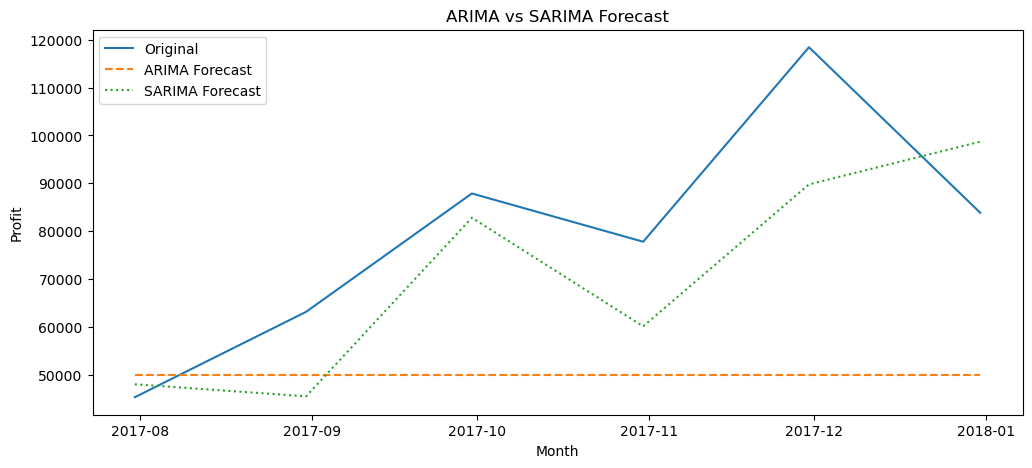

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(price[-6:],label="Original")
plt.plot(arima_forecast, label="ARIMA Forecast", linestyle='--')
plt.plot(sarima_forecast, label="SARIMA Forecast", linestyle=':')
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.title("ARIMA vs SARIMA Forecast")
plt.show()

In [37]:
print(f"ARIMA MAE: {mean_absolute_error(last_6, arima_forecast)}")
mse = mean_squared_error(last_6, arima_forecast)
print(f"ARIMA MSE: {mse}")
print(f"ARIMA RMSE: {np.sqrt(mse)}")
print(f"ARIMA R2: {r2_score(last_6, arima_forecast)}")
print("-"*30)
print(f"SARIMA MAE: {mean_absolute_error(last_6, sarima_forecast)}")
mse = mean_squared_error(last_6, sarima_forecast)
print(f"SARIMA MSE: {mse}")
print(f"SARIMA RMSE: {np.sqrt(mse)}")
print(f"SARIMA R2: {r2_score(last_6, sarima_forecast)}")

ARIMA MAE: 31045.88485173004
ARIMA MSE: 1378925911.452038
ARIMA RMSE: 37133.89168202059
ARIMA R2: -1.7136054127542728
------------------------------
SARIMA MAE: 14445.101562929629
SARIMA MSE: 283566613.7992294
SARIMA RMSE: 16839.436267263503
SARIMA R2: 0.4419657418202386


In [38]:
monthly_profit_office = dataset[dataset["Category"] == "Office Supplies"]['Sales'].resample('M').sum()
monthly_profit_furniture = dataset[dataset["Category"] == "Furniture"]['Sales'].resample('M').sum()
monthly_profit_tech = dataset[dataset["Category"] == "Technology"]['Sales'].resample('M').sum()

In [39]:
monthly_profit_office.head()

Order Date
2014-01-31     4851.080
2014-02-28     1071.724
2014-03-31     8605.879
2014-04-30    11155.074
2014-05-31     7135.624
Freq: M, Name: Sales, dtype: float64

In [40]:
monthly_profit_furniture.head()

Order Date
2014-01-31     6242.525
2014-02-28     1839.658
2014-03-31    14573.956
2014-04-30     7944.837
2014-05-31     6912.787
Freq: M, Name: Sales, dtype: float64

In [41]:
monthly_profit_tech.head()

Order Date
2014-01-31     3143.290
2014-02-28     1608.510
2014-03-31    32511.174
2014-04-30     9195.434
2014-05-31     9599.876
Freq: M, Name: Sales, dtype: float64

In [42]:
sarima_office = SARIMAX(monthly_profit_office[:-6], order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_office_result = sarima_office.fit()
sarima_office_forecast = sarima_office_result.forecast(steps=6)


sarima_furniture = SARIMAX(monthly_profit_furniture[:-6], order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_furniture_result = sarima_furniture.fit()
sarima_furniture_forecast = sarima_furniture_result.forecast(steps=6)


sarima_tech = SARIMAX(monthly_profit_tech[:-6], order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_tech_result = sarima_tech.fit()
sarima_tech_forecast = sarima_tech_result.forecast(steps=6)

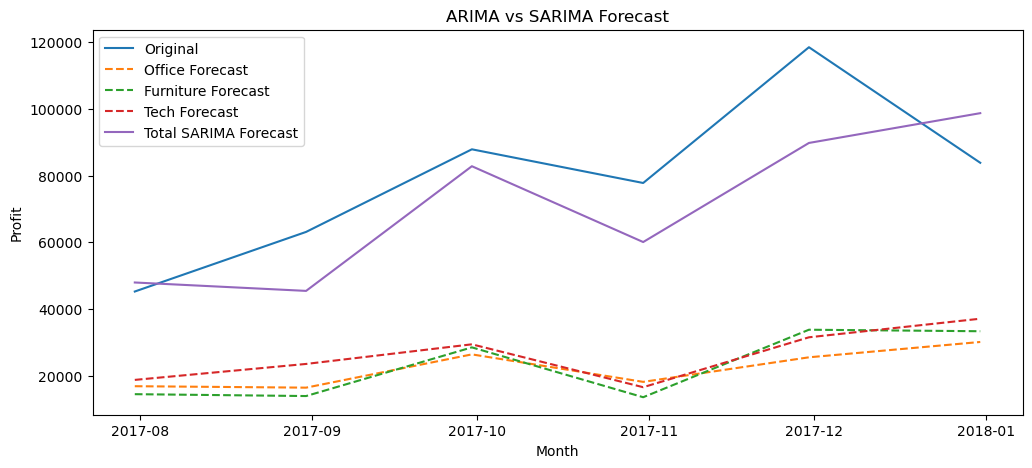

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(price[-6:],label="Original")
plt.plot(sarima_office_forecast, label="Office Forecast", linestyle='--')
plt.plot(sarima_furniture_forecast, label="Furniture Forecast", linestyle='--')
plt.plot(sarima_tech_forecast, label="Tech Forecast", linestyle='--')
plt.plot(sarima_forecast, label="Total SARIMA Forecast", linestyle='-')
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.title("ARIMA vs SARIMA Forecast")
plt.show()